# Model Prediction

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import torch

from monai.networks.nets import UNet

from skimage.measure import regionprops

from openeds import test_dataset

True unique values:	 metatensor([0., 1.])
Pred unique values:	 metatensor([0, 1, 2, 3], device='cuda:0')
Image shape:		 torch.Size([1, 640, 400])
True label shape:	 torch.Size([400, 640])
Pred label shape:	 torch.Size([640, 400])


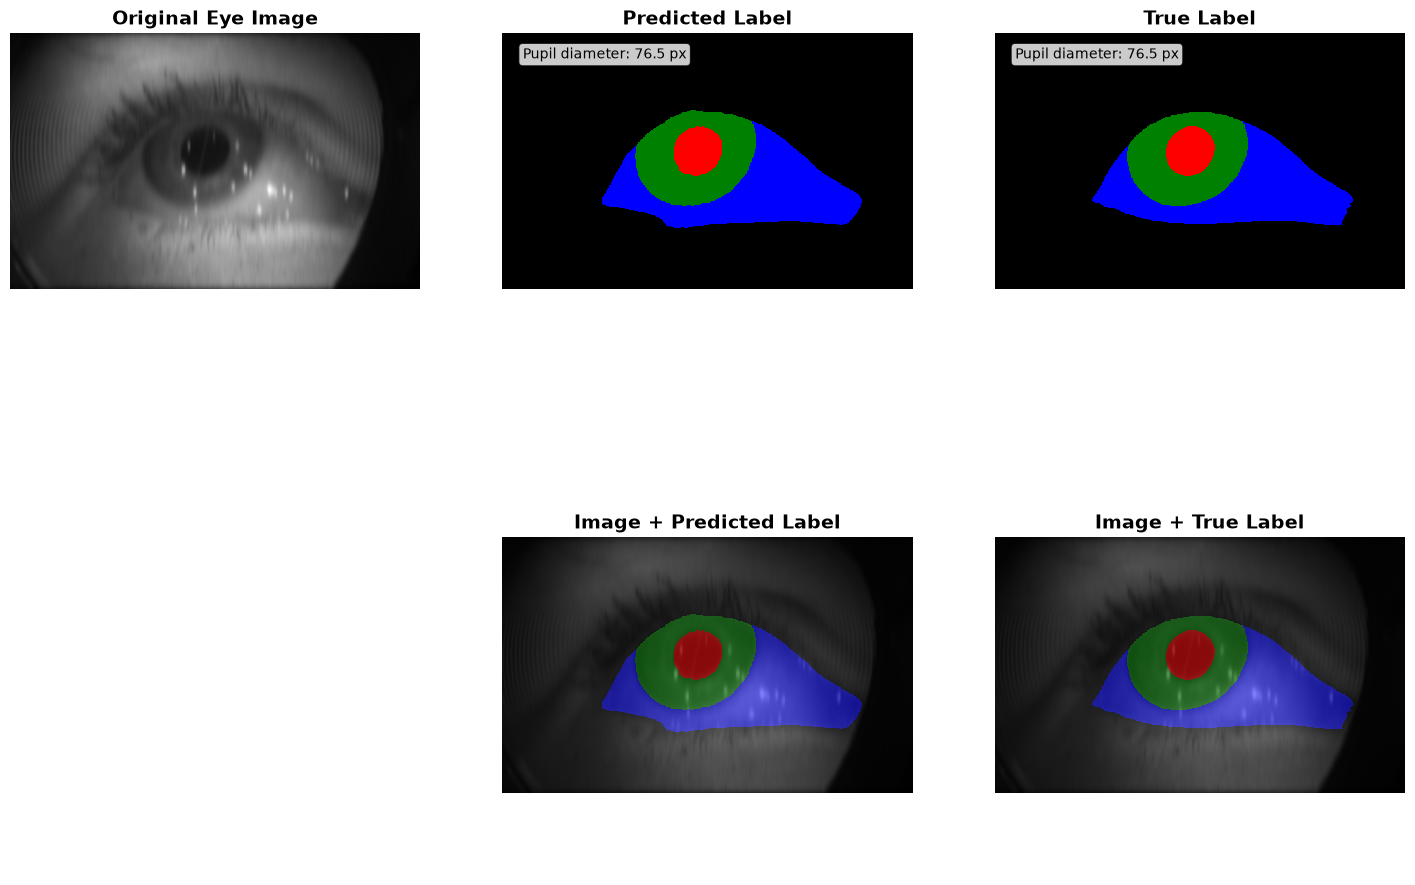

Pupil accuracy: 0.9895


In [31]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

checkpoint = torch.load('checkpoints/blur-mask-aug.pth')

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=4,
    channels=(8, 16, 32, 64, 128),
    strides=(2, 2, 2, 2),
    num_res_units=3,
    dropout=0.0
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
test_img = test_dataset[sample_idx]['img'].to(device)
test_mask = test_dataset[sample_idx]['mask'].to(device)
test_label = test_dataset[sample_idx]['label'].argmax(dim=0).to(device)

print('True unique values:\t', torch.unique(test_dataset[sample_idx]['label']))

with torch.no_grad():
    pred_logits = model(test_img.unsqueeze(0))
    pred_prob = torch.softmax(pred_logits, dim=1)
    pred_label = pred_prob.squeeze(0).argmax(dim=0)
    print('Pred unique values:\t', torch.unique(pred_label))

print('Image shape:\t\t', test_img.shape)
print('True label shape:\t', test_label.shape)
print('Pred label shape:\t', pred_label.shape)

pred_label = pred_label.permute(1, 0).cpu()
test_img = test_img.permute(2, 1, 0).cpu()
test_label = test_label.permute(0, 1).cpu()


def compute_pupil_diameter(img):
    pupil = (img == 3).to(torch.int32)
    props = regionprops(pupil.numpy())
    if len(props) != 1:
        raise RuntimeError("Unable to compute pupil diameter. Check if pupil corresponds to class 3.")
    min_row, min_col, max_row, max_col = props[0].bbox
    return ((max_col - min_col) + (max_row - min_row)) / 2


cmap = mcolors.ListedColormap(['black', 'blue', 'green', 'red'])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Original Eye Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

bbox_props = dict(boxstyle='round', facecolor='white', alpha=0.8)

axes[0, 1].imshow(pred_label, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
axes[0, 1].set_title('Predicted Label', fontsize=14, fontweight='bold')
pred_pupil = (pred_label == 3).to(torch.int32)
axes[0, 1].text(0.05, 0.9, f'Pupil diameter: {compute_pupil_diameter(pred_label)} px', transform=axes[0, 1].transAxes, bbox=bbox_props)
axes[0, 1].axis('off')

axes[0, 2].imshow(test_label, cmap=cmap, vmin=0, vmax=3, interpolation='nearest')
axes[0, 2].set_title('True Label', fontsize=14, fontweight='bold')
axes[0, 2].text(0.05, 0.9, f'Pupil diameter: {compute_pupil_diameter(test_label)} px', transform=axes[0, 2].transAxes, bbox=bbox_props)
axes[0, 2].axis('off')

axes[1, 0].axis('off')

axes[1, 1].imshow(test_img, cmap='gray')
axes[1, 1].imshow(pred_label, cmap=cmap, vmin=0, vmax=3, alpha=0.5, interpolation='nearest')
axes[1, 1].set_title('Image + Predicted Label', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(test_img, cmap='gray')
axes[1, 2].imshow(test_label, cmap=cmap, vmin=0, vmax=3, alpha=0.5, interpolation='nearest')
axes[1, 2].set_title('Image + True Label', fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.show()

pupil_accuracy = (((pred_label == 3) * (test_label == 3)).float().sum() / (test_label == 3).float().sum()).item()
print(f'Pupil accuracy: {pupil_accuracy:.4f}')

# Dataset Content

In [ ]:
%load_ext autoreload

Original train images:	 21944
Original val images:	 2743
Original test images:	 2744
Augmented train images:	 76804
Augmented val images:	 38402
Augmented test images:	 38404
Original train images:	 21944
Original val images:	 2743
Original test images:	 2744
Augmented train images:	 76804
Augmented val images:	 38402
Augmented test images:	 38404
Original train images:	 21944
Original val images:	 2743
Original test images:	 2744
Augmented train images:	 76804
Augmented val images:	 38402
Augmented test images:	 38404
Original train images:	 21944
Original val images:	 2743
Original test images:	 2744
Augmented train images:	 76804
Augmented val images:	 38402
Augmented test images:	 38404


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

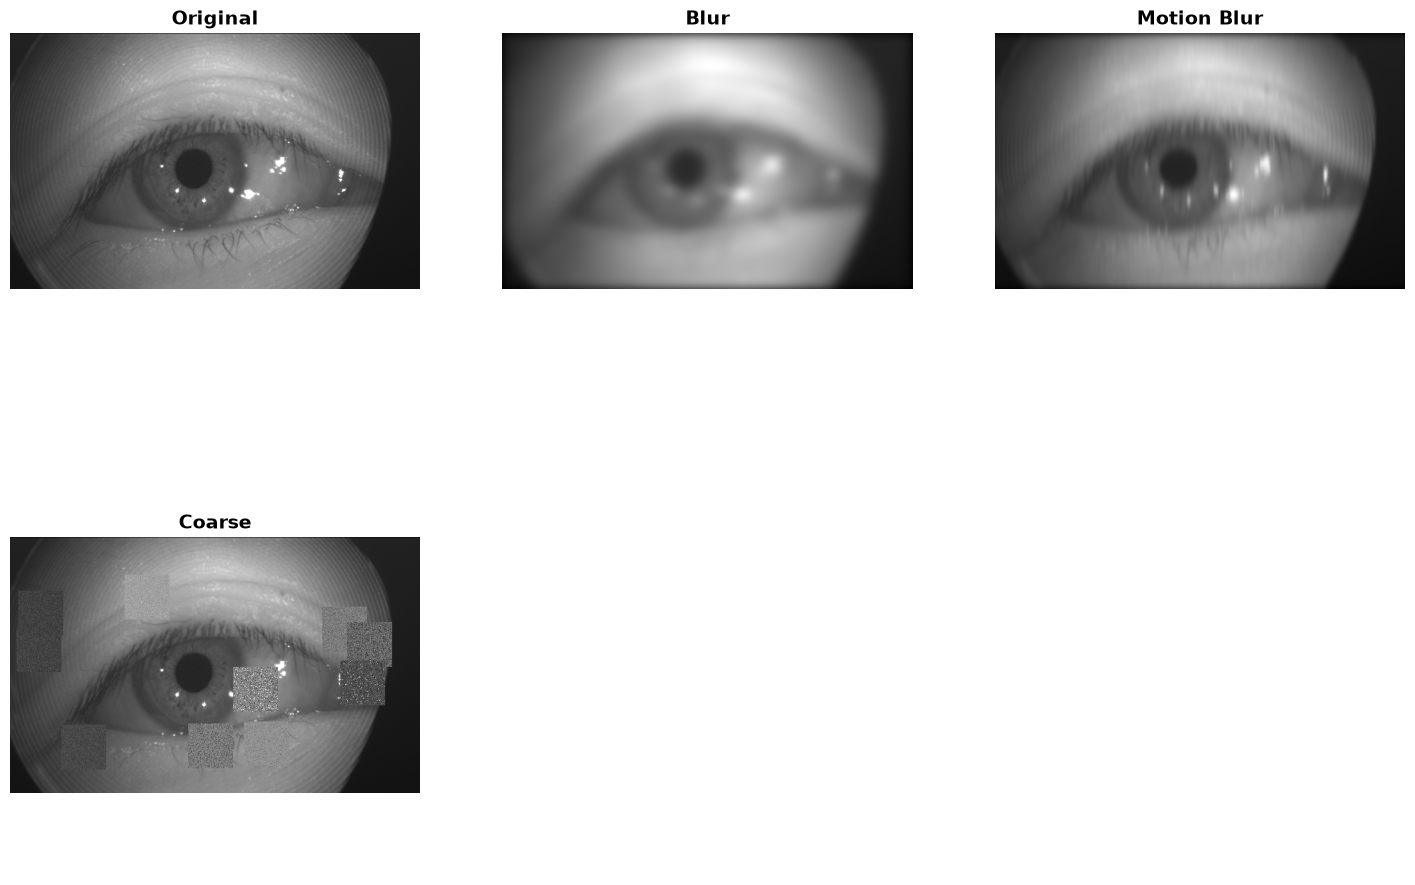

In [ ]:
%autoreload 2
import random

import matplotlib.pyplot as plt

from monai.data import Dataset

from openeds import train_files, base_transforms, blur_transforms, motion_blur_transforms, coarse_transforms

sample_idx = random.randint(0, len(train_files))

def sample_transformed(transforms):
    dataset = Dataset(
        data=train_files,
        transform=transforms,
    )
    return dataset[sample_idx]['img'].permute(2, 1, 0)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(sample_transformed(base_transforms), cmap='gray')
axes[0, 0].set_title('Original', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sample_transformed(blur_transforms), cmap='gray')
axes[0, 1].set_title('Blur', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(sample_transformed(motion_blur_transforms), cmap='gray')
axes[0, 2].set_title('Motion Blur', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(sample_transformed(coarse_transforms), cmap='gray')
axes[1, 0].set_title('Coarse', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].axis('off')

axes[1, 2].axis('off')